# Case 1: 2D Facial Pose (MATB) — reproduction

This notebook walks through the full Case-1 pipeline on the MATB facial-pose data
and reproduces the paper's figure (pupil velocity, pupil %REC, cross gaze–head
%REC, and pupil %DET across Low/Moderate/High cognitive load).

It follows the workflow a user would run:

1. **Load & preprocess** a trial (confidence mask → interpolation → filter).
2. **Choose the embedding parameters** `(τ, m)` from AMI/FNN evidence — the
   framework proposes, *you* commit.
3. **Run the reproduction** across participants.
4. **Reproduce the figure.**

All analysis logic lives in the library; this notebook only calls it.

## Configuration

Set the data location and the **run toggle**. `RUN_FULL = False` analyzes a fast
subset (good for iterating); `RUN_FULL = True` runs all 72 participants (216
trials, ~15–25 min) to reproduce the published figure.

In [7]:
import glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# >>> point this at your MATB raw OpenPose exports <<<
DATA_DIR = "/Volumes/X9_Pro/MRes_MATB/Pose/data/raw_data/experimental_pose"

# --- run toggle ---
RUN_FULL   = False   # False = quick subset; True = all participants (the paper figure)
N_SUBSET   = 12      # trials analyzed when RUN_FULL is False
N_EMBED     = 6      # trials pooled for the AMI/FNN evidence

files = sorted(glob.glob(f"{DATA_DIR}/*.csv"))
run_files = files if RUN_FULL else files[:N_SUBSET]
print(f"{len(files)} trials available; analyzing {len(run_files)} "
      f"({'FULL' if RUN_FULL else 'subset'}).")

216 trials available; analyzing 12 (subset).


## 1. Load and preprocess a trial

`load_matb_file` reads the raw OpenPose export (`x{n}, y{n}, prob{n}`, 1-based) and
returns a `PoseSequence`. `preprocess` applies the Case-1 settings: confidence
mask at 0.30, run-limited interpolation (≤ 60 frames), and a 4th-order 10 Hz
zero-phase Butterworth filter. The coverage plot is the preprocessing checkpoint.

{'source_file': '/Volumes/X9_Pro/MRes_MATB/Pose/data/raw_data/experimental_pose/402_H.csv', 'n_frames': 28835, 'n_keypoints': 70, 'dims': 2, 'frame_rate': 60.0, 'duration_s': 480.583, 'has_confidence': True, 'missing_fraction': 0.0, 'stages_applied': ['confidence_mask', 'provisional_interpolation', 'butterworth_filter'], 'meta': {'participant': '402', 'condition': 'H'}}


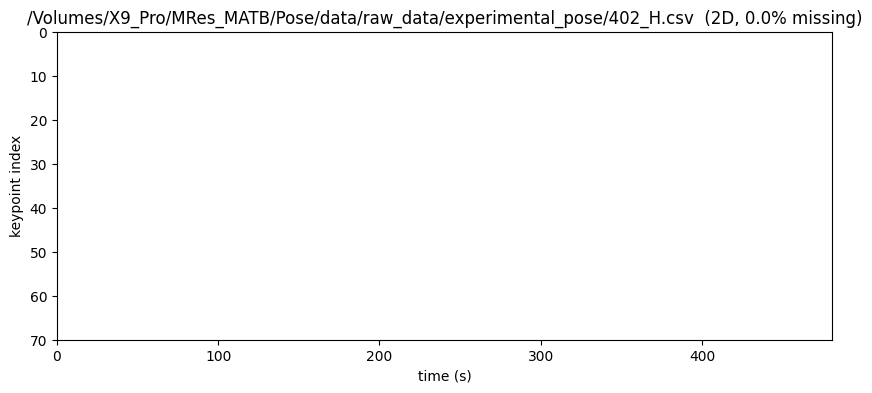

In [8]:
from pose_dynamics.case_studies.matb import load_matb_file, preprocess

seq = preprocess(load_matb_file(run_files[0]))
print(seq.summary())
seq.plot_coverage();

## 2. Choosing the embedding parameters (human-in-the-loop)

AMI and FNN are computed across many signals (here, per-keypoint speed pooled over
a handful of trials). The framework **presents the evidence and proposes** `(τ, m)`
using relative-shape/plateau logic for τ and the diminishing-returns knee for m —
but it does **not** decide. You read the plots and commit.

Evidence from 60 of 420 signals.

Delay (tau) — relative-shape / plateau heuristic (proposal, confirm from the plot):
  - first prominent local minimum (smoothed) at lag None.
  - plateau onset (diminishing returns) at lag 17.
  - relative 1/e crossing at lag 3.
  - per-signal median suggestion: 16.0.
  => proposed tau = 17.

Dimension (m) — FNN diminishing-returns knee at tau=17:
  - knee (elbow of the FNN curve): 4.
  - first dimension with FNN <= 10% (noise floor): 7.
  - per-signal median: 4.0.
  => proposed m = 4.

NOTE: these are proposals, not decisions. Inspect the curves and their spread, then commit a single (tau, m) with evidence.commit(tau, m).


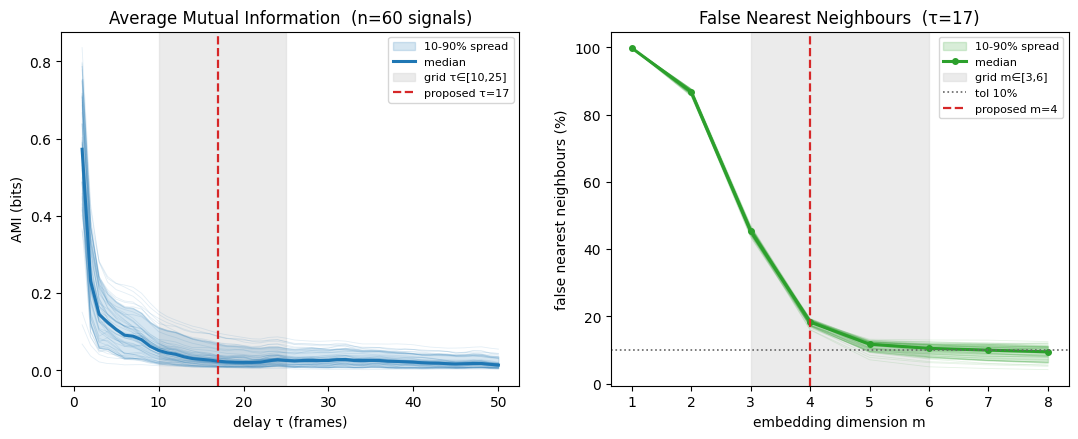

In [9]:
from pose_dynamics.embedding import (select_embedding, pool_signals, magnitude_channels,
                                     plot_embedding_evidence, plot_embedding_variability)

sample = [preprocess(load_matb_file(f)) for f in files[:N_EMBED]]
signals = pool_signals(sample, magnitude_channels)

evidence = select_embedding(signals, tau_grid=(10, 25), m_grid=(3, 6),
                            ami_max_lag=50, fnn_max_dim=8, subset=60, seed=0)
plot_embedding_evidence(evidence)
print(evidence.justification)

In [ ]:
# optional: does (tau, m) drift systematically across conditions?
plot_embedding_variability(evidence, group_by="condition");

### Commit the choice

The evidence proposes τ≈17–20 (AMI plateau) and m=4 (FNN knee). Consistent with
the paper, we commit **τ = 20, m = 4**, applied fixed across the whole study.
`evidence.commit` records the decision (and warns if it is outside the presented
grid or below the proposed dimension). These are exactly the values in the Case-1
config (`pose_dynamics.case_studies.matb.config`: `TAU = 20`, `M = 4`).

In [ ]:
params = evidence.commit(tau=20, m=4, notes="Case 1: AMI plateau ~ quarter-cycle; FNN knee at 4")
params.to_dict()

## 3. Run the reproduction

`run_reproduction` streams every selected trial through the full Case-1 pipeline:

- normalize to screen → **anisotropic Procrustes** emitting *both* streams
  (aligned geometry **and** head-motion parameters),
- pupil displacement (two-eye offset) on the aligned coordinates,
- 60 s windows (50% overlap), then per window: pupil velocity RMS (linear),
  auto-RQA of the pupil signal, and cross-RQA between head motion and pupil.

Controlled by the `RUN_FULL` toggle above.

In [ ]:
from pose_dynamics.case_studies.matb import run_reproduction

df = run_reproduction(run_files, template_sample=24, progress=True)
print(f"{len(df)} window-rows")
df.head()

In [ ]:
# save the tidy results (one row per trial x window)
df.to_csv("matb_case1_results.csv", index=False)

## 4. Reproduce the figure

Group-averaged metrics (mean ± SEM across windows) for each load level — the same
four panels as the paper's Case-1 figure.

In [ ]:
from pose_dynamics.case_studies.matb import plot_case1_figure
plot_case1_figure(df);

## 5. Inferential statistics (dataset-specific)

The package emits only the tidy results table; the models here are specific to the
MATB dataset and live in the notebook. Linear mixed-effects models with a fixed
effect of cognitive-load condition (Low as reference) and a random intercept for
participant give the condition effects (Moderate, High vs. Low) per metric.

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd
import warnings; warnings.simplefilter("ignore")

coef_rows = []
for metric in ["pupil_metric_vel_rms", "pupil_metric_perc_recur",
               "pupil_metric_perc_determ", "crqa_head_pupil_mag_perc_recur"]:
    m = smf.mixedlm(f"{metric} ~ C(condition, Treatment('L'))",
                    df, groups=df["participant"]).fit()
    for term, label in [("C(condition, Treatment('L'))[T.M]", "M"),
                        ("C(condition, Treatment('L'))[T.H]", "H")]:
        coef_rows.append({"metric": metric, "vs_Low": label,
                          "beta": m.params[term], "SE": m.bse[term], "p": m.pvalues[term]})
pd.DataFrame(coef_rows).round(4)